In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

In [21]:
#ADF정상성 검정
def adf_test(x):

    indices = ['검정통계량', 'p-value', '# 시차 사용 수', '# 관측치 사용 수']
    
    adf_test = adfuller(x, autolag='AIC')
    results = pd.Series(adf_test[0:4], index=indices)
    
    for key, value in adf_test[4].items():
        results[f'임계값(Critical Value)[{key}]'] = value

    return results

#KPSS 정상성 검정
def kpss_test(x, h0_type='c'):
    
    indices = ['검정통계량', 'p-value', '# 시차 사용 수']

    kpss_test = kpss(x, regression=h0_type)
    results = pd.Series(kpss_test[0:3], index=indices)
    
    for key, value in kpss_test[3].items():
        results[f'임계값(Critical Value)[{key}]'] = value

    return results

### 데이터 불러오기(금시세 2000~2011년도)

In [14]:
# Yahoo Finance에서 수집한 CSV
file_path = "../Data-collection/dailyStock"
target = "GC=F"
file_path = f"{file_path}/{target}.csv"
df = pd.read_csv(file_path, encoding="utf-8")


df['Date'] = pd.to_datetime(df['Date']) # 날짜로 변환
df = df.set_index('Date')               ## Date를 인덱스로 설정
df = df.loc['2000-01-01':'2011-12-31']  # 분석 기간
df = df['Close'].resample('ME').mean()  # 월평균 가격 계산
df = df.to_frame(name='price')          # 컬럼명 변경

### ADF 정상성 검정 결과(귀무가설 비정상성)

In [19]:
adf_test(df.price)

검정통계량                         1.820194
p-value                       0.998388
# 시차 사용 수                     0.000000
# 관측치 사용 수                  136.000000
임계값(Critical Value)[1%]      -3.479372
임계값(Critical Value)[5%]      -2.883037
임계값(Critical Value)[10%]     -2.578234
dtype: float64

### KPSS 정상성 검정 결과(귀무가설 정상성)

In [22]:
kpss_test(df.price)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21932\251177870.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(x, regression=h0_type)


검정통계량                        1.868189
p-value                      0.010000
# 시차 사용 수                    6.000000
임계값(Critical Value)[10%]     0.347000
임계값(Critical Value)[5%]      0.463000
임계값(Critical Value)[2.5%]    0.574000
임계값(Critical Value)[1%]      0.739000
dtype: float64

### ACF/PACF 그래프

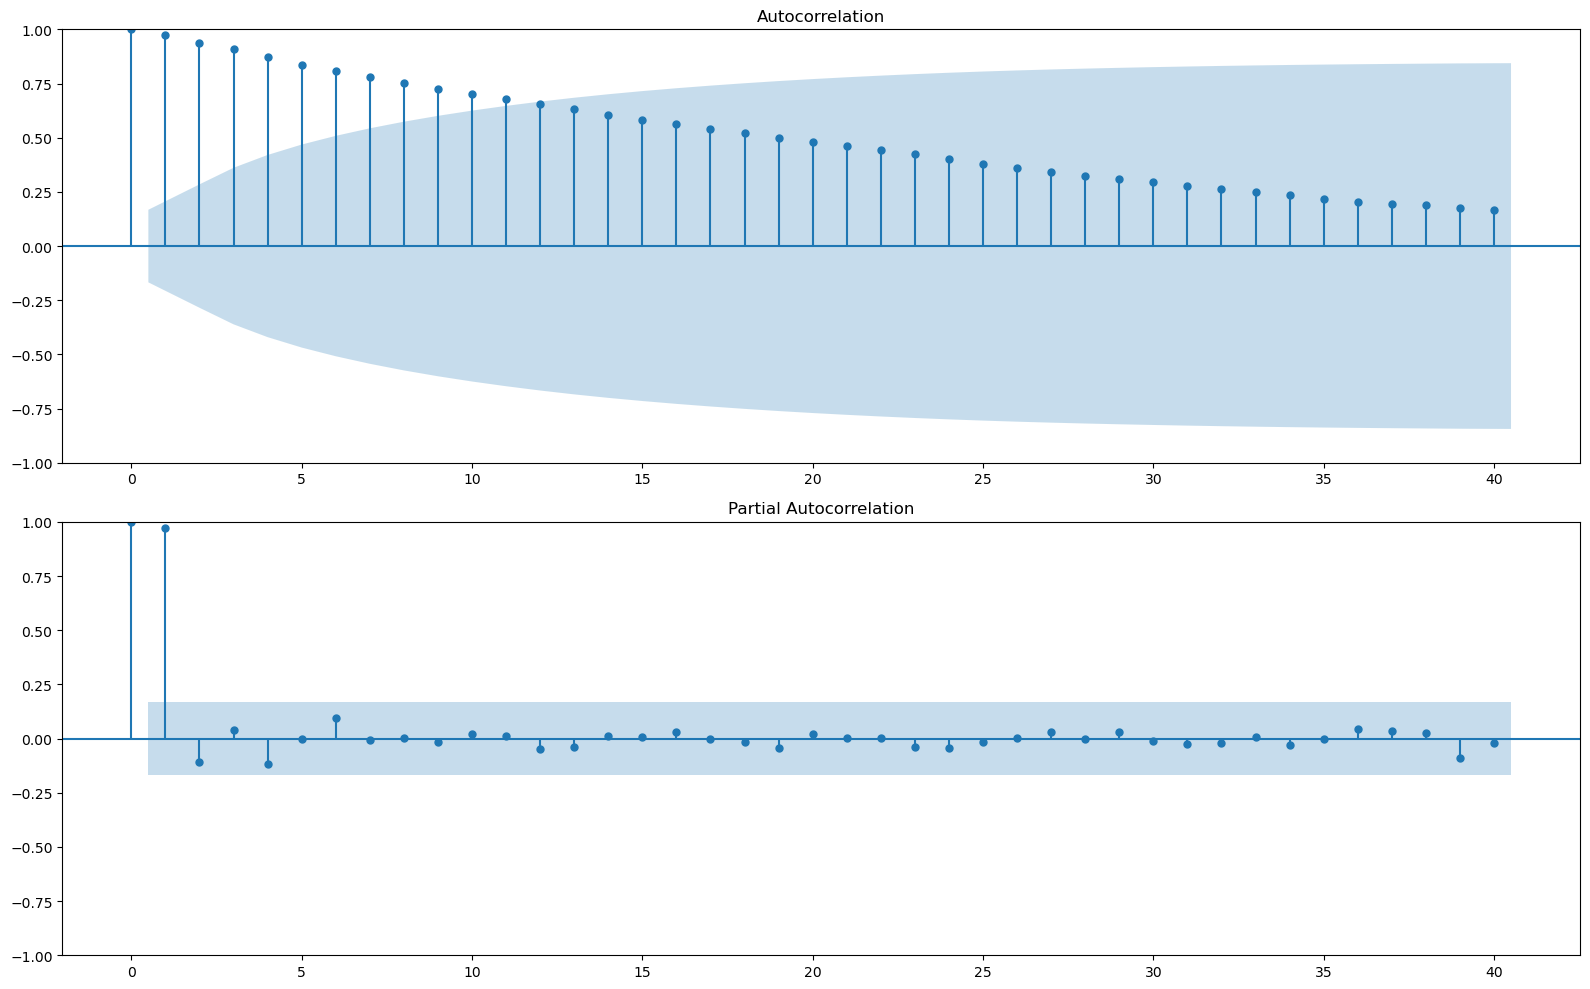

In [26]:
N_LAGS = 40
SIGNIFICANCE_LEVEL = 0.05

fig, ax = plt.subplots(2, 1)
plot_acf(df.price, ax=ax[0], lags=N_LAGS, 
         alpha=SIGNIFICANCE_LEVEL)
plot_pacf(df.price, ax=ax[1], lags=N_LAGS, 
          alpha=SIGNIFICANCE_LEVEL)

fig.set_size_inches(16, 10)

plt.tight_layout()
plt.show()